<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>LLM Engineering Masterclass</h1>
<h1>4. Evaluated RAG: Retrieval You Can Measure</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [18]:
import os
import json
import re
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import watermark
from tqdm.auto import tqdm

# Data downloads/cache and figure output locations
_ROOT = Path.cwd()
_DATA = _ROOT / "data"
_OUT = _ROOT / "output"
_DATA.mkdir(parents=True, exist_ok=True)
_OUT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(_DATA / "huggingface"))
os.environ.setdefault("HF_DATASETS_CACHE", str(_DATA / "huggingface" / "datasets"))
os.environ.setdefault("KAGGLEHUB_CACHE", str(_DATA / "kagglehub"))

from collections import Counter
from pprint import pprint

%load_ext watermark
%matplotlib inline


The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark


In [19]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.17.1

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.6.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 4a6dba6ecf328d3e09b6b48d7053d924ebc0545f

json      : 2.0.9
matplotlib: 3.11.1
numpy     : 2.5.3
openai    : 3.13.0
pandas    : 3.0.5
re        : 2.2.1
tqdm      : 4.70.1
watermark : 2.6.0



In [20]:
plt.style.use("d4sci.mplstyle")
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Retrieval first

Most bad RAG answers trace back to retrieval. The model never saw the right passage, so it improvised. Measure retrieval on its own, before generation enters the picture.

Two metrics carry the section:

1. **recall@k**: did a relevant document land in the top k?
2. **MRR**: how high did the first relevant document rank?

Banking77 gives us the hard half of a RAG benchmark for free: real customer questions labeled with the topic that answers them. We build the other half, the help center, in the next cell.

# Load the data and taxonomy from Notebook 1

In [21]:
taxonomy = json.loads((_DATA / "banking77_taxonomy.json").read_text())
QUEUES, INTENTS = taxonomy["queues"], taxonomy["intents"]

train = pd.read_csv(_DATA / "banking77_train.csv")
test = pd.read_csv(_DATA / "banking77_test.csv")

from openai import OpenAI

openai_client = OpenAI()

DEFAULT_MODEL = "gpt-4.1-mini"
EMBED_MODEL = "text-embedding-3-small"

def pmap(fn, items, workers=8):
    with ThreadPoolExecutor(max_workers=workers) as pool:
        return list(tqdm(pool.map(fn, items), total=len(items)))


# The knowledge base: one article per intent

Banking77 has no help center, so we write one. For each of the 77 intents the model drafts a short article from three training examples. The result is cached to disk, so this runs once.

Because every article maps to one intent, the retrieval labels come for free: a test message with intent X has article X as its relevant document. Train examples shaped the articles, test messages ask the questions. No leakage.

In [22]:
KB_PATH = _DATA / "banking77_kb.jsonl"

ARTICLE_SYSTEM = (
    "You write help center articles for a mobile banking app.\n"
    "Write one article of 60 to 90 words that answers customers who ask questions like the examples.\n"
    "State the policy, the steps and the timing where relevant. Invent plausible specifics.\n"
    "Plain text. No markdown. No greeting."
)

def write_article(intent):
    examples = train.loc[train["intent"] == intent, "text"].sample(3, random_state=0).tolist()
    title = intent.replace("_", " ").capitalize()
    response = openai_client.chat.completions.create(
        model=DEFAULT_MODEL,
        messages=[{"role": "system", "content": ARTICLE_SYSTEM},
                  {"role": "user", "content": f"Title: {title}\nExample questions:\n- " + "\n- ".join(examples)}],
        temperature=0,
    )
    return {"id": intent, "title": title, "text": response.choices[0].message.content.strip()}

if KB_PATH.exists():
    kb = [json.loads(line) for line in KB_PATH.read_text().splitlines()]
else:
    kb = pmap(write_article, INTENTS)
    KB_PATH.write_text("\n".join(json.dumps(doc) for doc in kb) + "\n")

print(len(kb), "articles")
print(kb[0]["title"])
print(kb[0]["text"])


77 articles
Activate my card
To activate your new card, open the mobile banking app and go to the "Cards" section. Select the card you want to activate and tap "Activate Card." Follow the on-screen instructions, which may include entering the last four digits of your card and your PIN. Activation is usually instant, allowing you to use your card immediately. If you experience any issues, please contact customer support through the app for assistance.


# Chunking

These articles are short, so most map to a single chunk. The function matters anyway: chunk size is a measurable knob, and the exercise at the end turns it.

In [23]:
def chunk(text, max_chars=500, overlap=50):
    """Greedy character chunking. Simple beats clever until measurements say otherwise."""
    if len(text) <= max_chars:
        return [text]
    pieces = []
    start = 0
    while start < len(text):
        pieces.append(text[start:start + max_chars])
        start += max_chars - overlap
    return pieces

def build_chunks(kb, **kwargs):
    chunks = []
    for doc in kb:
        for i, piece in enumerate(chunk(doc["text"], **kwargs)):
            chunks.append({"chunk_id": f"{doc['id']}-{i}", "doc_id": doc["id"],
                           "title": doc["title"], "text": piece})
    return chunks

chunks = build_chunks(kb)
print(len(chunks), "chunks from", len(kb), "articles")


89 chunks from 77 articles


# Embeddings and dense retrieval

A numpy matrix is a fine vector store below roughly 100 thousand chunks. Reach for a dedicated store when you need filters, live updates or scale, not because a tutorial told you to.

In [24]:
def embed(texts):
    response = openai_client.embeddings.create(model=EMBED_MODEL, input=texts)
    vectors = np.array([item.embedding for item in response.data])
    return vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

chunk_matrix = embed([f"{c['title']}\n{c['text']}" for c in chunks])
chunk_matrix.shape


(89, 1536)

In [25]:
def make_retriever(chunks, chunk_matrix):
    def retrieve(query, k=5):
        query_vector = embed([query])[0]
        scores = chunk_matrix @ query_vector
        order = np.argsort(scores)[::-1][:k]
        return [{**chunks[i], "score": float(scores[i])} for i in order]
    return retrieve

retrieve = make_retriever(chunks, chunk_matrix)

for hit in retrieve("I was charged twice for the same purchase", k=3):
    print(f"{hit['score']:.3f}  {hit['doc_id']}")


0.730  transaction_charged_twice
0.473  extra_charge_on_statement
0.406  transfer_fee_charged


# The retrieval golden set

Seventy seven real customer messages, one per intent, sampled from the test split with a seed that differs from Notebook 2. Each one has exactly one relevant article. Near neighbour intents make recall@1 a real test.

In [26]:
retrieval_golden = (test.groupby("intent", group_keys=False)
                        .sample(1, random_state=7)
                        .reset_index(drop=True))
retrieval_golden = [{"query": row["text"], "relevant": {row["intent"]}}
                    for row in retrieval_golden.to_dict("records")]

def recall_at_k(ranked_doc_ids, relevant, k):
    return float(any(doc_id in relevant for doc_id in ranked_doc_ids[:k]))

def reciprocal_rank(ranked_doc_ids, relevant):
    for rank, doc_id in enumerate(ranked_doc_ids, start=1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0

def evaluate_retrieval(retriever, k_values=(1, 3, 5, 10)):
    def score(item):
        ranked = [hit["doc_id"] for hit in retriever(item["query"], k=max(k_values))]
        row = {"query": item["query"], "relevant": next(iter(item["relevant"])),
               "top1": ranked[0], "mrr": reciprocal_rank(ranked, item["relevant"])}
        for k in k_values:
            row[f"recall@{k}"] = recall_at_k(ranked, item["relevant"], k)
        return row
    return pd.DataFrame(pmap(score, retrieval_golden))

baseline = evaluate_retrieval(retrieve)
baseline.drop(columns=["query", "relevant", "top1"]).mean().round(3)


  0%|          | 0/77 [00:00<?, ?it/s]

mrr          0.823
recall@1     0.740
recall@3     0.883
recall@5     0.935
recall@10    0.974
dtype: float64

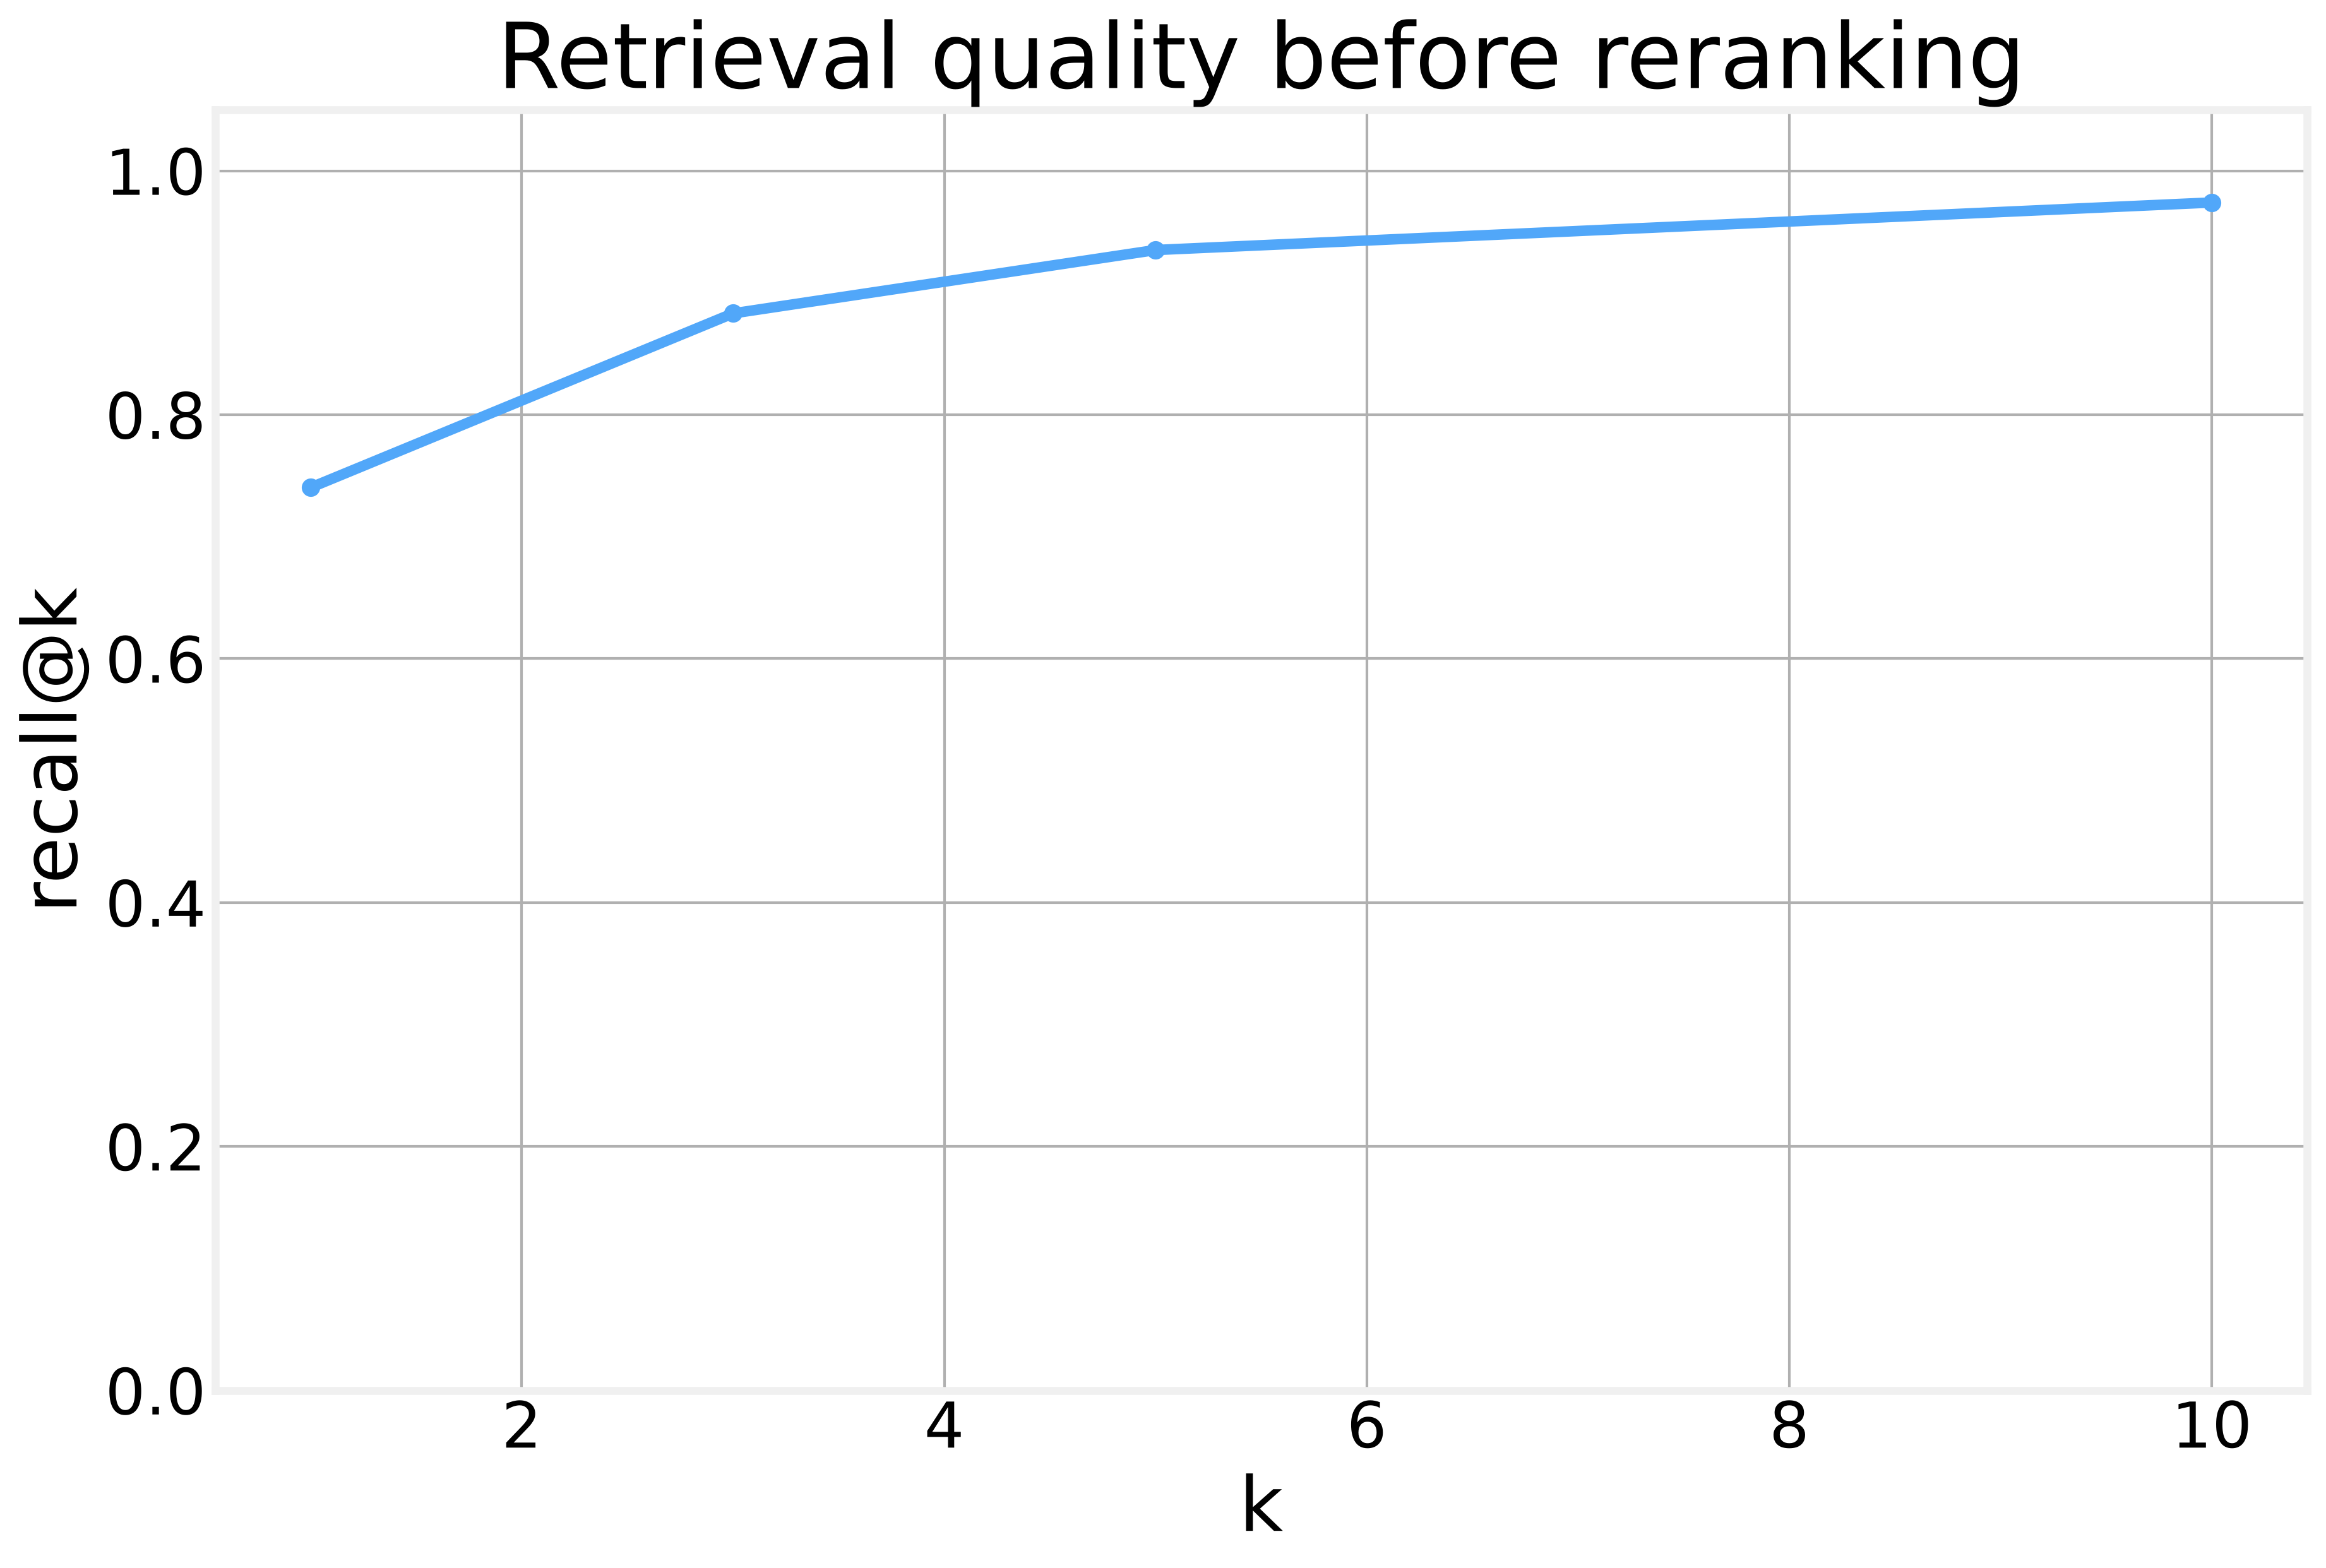

In [ ]:
k_values = [1, 3, 5, 10]
recall_curve = [baseline[f"recall@{k}"].mean() for k in k_values]

fig, ax = plt.subplots()
ax.plot(k_values, recall_curve, "o-", color=colors[0])
ax.set_xlabel("k")
ax.set_ylabel("recall@k")
ax.set_ylim(0, 1.05)
ax.set_title("Retrieval quality before reranking")
fig.tight_layout()

In [28]:
# Which queries miss at k=1? Almost always a neighbouring intent.
baseline.loc[baseline["recall@1"] == 0, ["query", "relevant", "top1"]].head(12)


,query,relevant,top1
2,"I got my American Express in Apple Pay, why is...",apple_pay_or_google_pay,top_up_failed
4,Can I space out how often money is transferred...,automatic_top_up,transfer_timing
5,How long does it take for an international tra...,balance_not_updated_after_bank_transfer,transfer_timing
12,How long does it take to get my card? Can I ch...,card_delivery_estimate,card_arrival
13,Can I reactivate my lost card that I found thi...,card_linking,lost_or_stolen_card
16,I think there has been a purchase made that wa...,card_payment_not_recognised,transaction_charged_twice
25,I have no idea why my card payment did not work.,declined_card_payment,card_payment_not_recognised
26,"I need your help to check my account, please! ...",declined_cash_withdrawal,card_not_working
29,How many disposable virtual cards can I have?,disposable_card_limits,get_disposable_virtual_card
33,"I need AUD not GBP, how do I change it?",exchange_via_app,receiving_money


# Reranking

Embeddings compress each text alone, so near misses happen at the top of the ranking. A reranker reads the message and each candidate together and reorders the pool.

The pattern: retrieve a wide pool with embeddings, rerank, keep the top few. We use an LLM as the reranker to stay dependency free today. Cross encoder models do the same job cheaper at scale.

In [29]:
def extract_json(text):
    match = re.search(r"[\[{].*[\]}]", text, re.DOTALL)
    return match.group(0) if match else text

RERANK_SYSTEM = (
    "Score each help center article for relevance to the customer message on a 0 to 10 scale.\n"
    "Reply with JSON only: a list of objects with keys index and score."
)

def llm_rerank(query, candidates, model=DEFAULT_MODEL):
    listing = "\n".join(
        f"{i}. [{c['doc_id']}] {c['title']}: {c['text'][:200]}"
        for i, c in enumerate(candidates)
    )
    response = openai_client.chat.completions.create(
        model=model,
        messages=[{"role": "system", "content": RERANK_SYSTEM},
                  {"role": "user", "content": f"Message: {query}\n\nArticles:\n{listing}"}],
        temperature=0,
    )
    scores = {item["index"]: item["score"]
              for item in json.loads(extract_json(response.choices[0].message.content))}
    order = sorted(range(len(candidates)), key=lambda i: scores.get(i, 0), reverse=True)
    return [candidates[i] for i in order]

def retrieve_rerank(query, k=5, pool=15):
    """Cast a wide net with embeddings. Reorder the pool with the reranker."""
    return llm_rerank(query, retrieve(query, k=pool))[:k]


In [30]:
reranked = evaluate_retrieval(retrieve_rerank, k_values=(1, 3, 5))

metrics = ["recall@1", "recall@3", "recall@5", "mrr"]
comparison = pd.DataFrame({
    "baseline": baseline[metrics].mean(),
    "reranked": reranked[metrics].mean(),
}).round(3)
comparison


  0%|          | 0/77 [00:00<?, ?it/s]

,baseline,reranked
recall@1,0.740,0.792
recall@3,0.883,0.961
recall@5,0.935,0.961
mrr,0.823,0.870


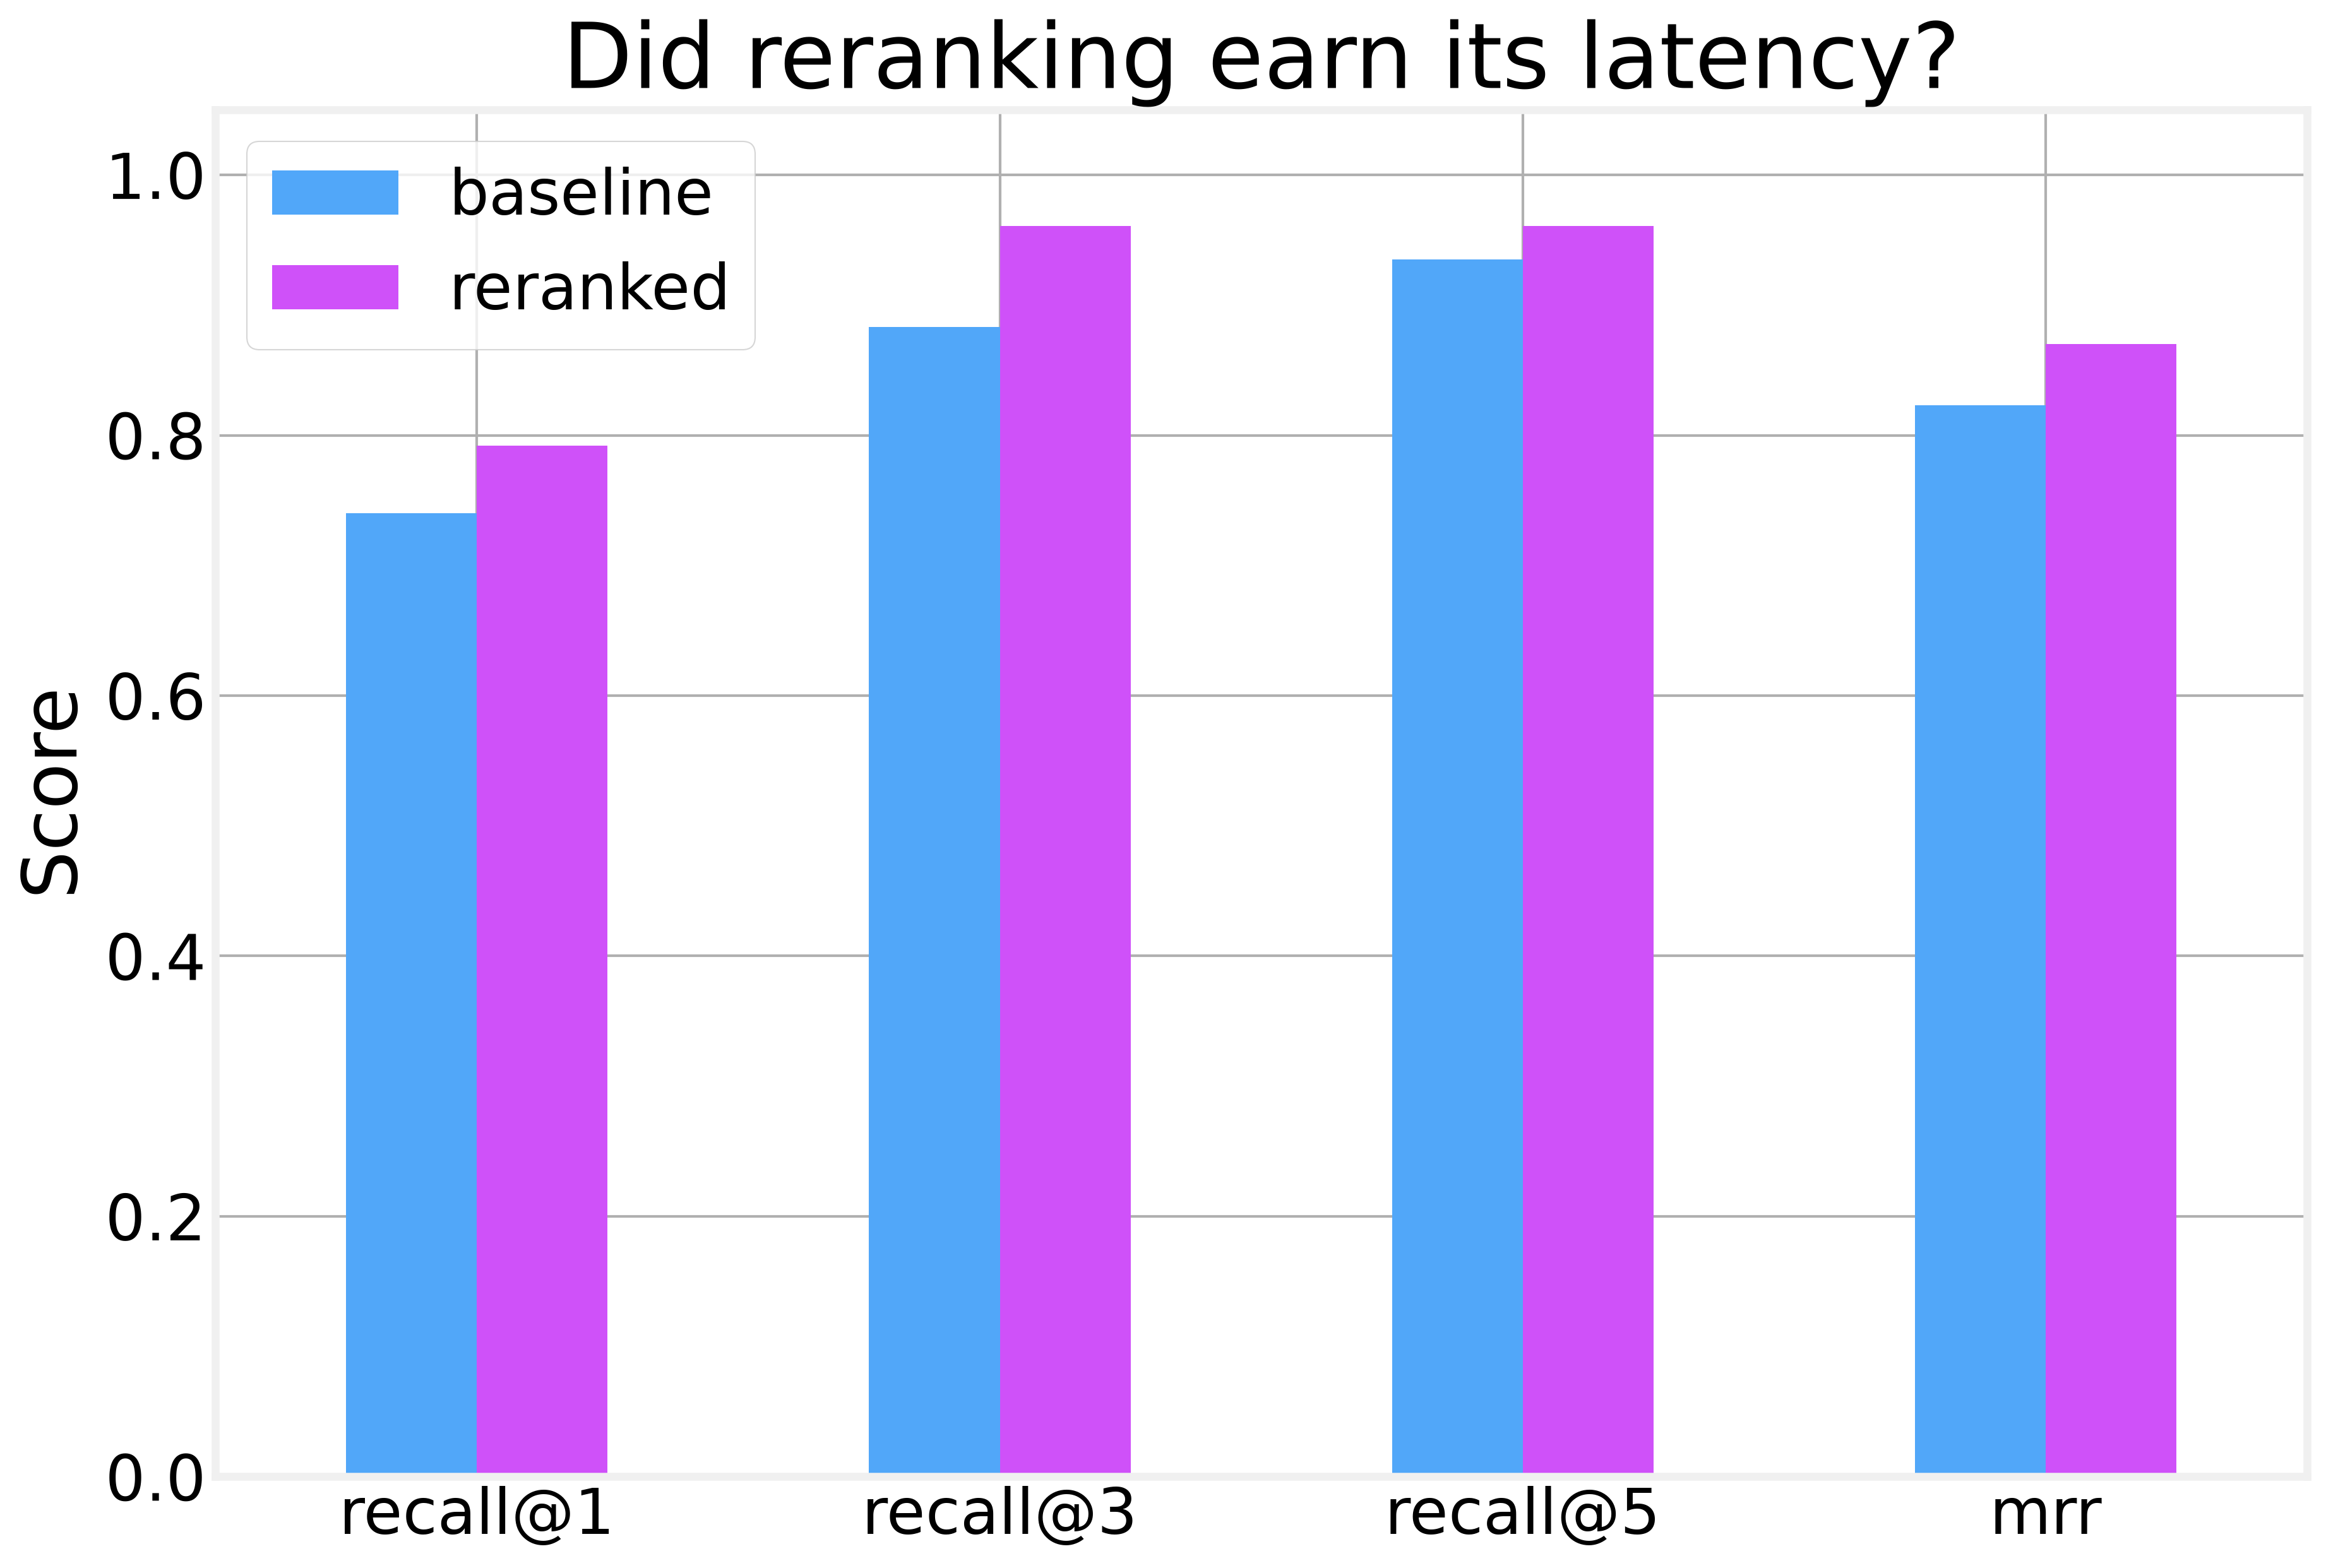

In [ ]:
fig, ax = plt.subplots()
comparison.plot.bar(ax=ax, color=[colors[0], colors[1]])
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Did reranking earn its latency?")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()

# Grounded generation

Only now does the generator enter. Three rules do most of the work: a context budget, article citations and permission to say the answer is not there.

In [32]:
def assemble_context(hits, budget_chars=2000):
    """Pack the best hits under a budget. Tag each block with its doc id."""
    parts, used = [], 0
    for hit in hits:
        block = f"[{hit['doc_id']}] {hit['title']}\n{hit['text']}"
        if used + len(block) > budget_chars:
            break
        parts.append(block)
        used += len(block)
    return "\n\n".join(parts)

RAG_SYSTEM = (
    "You answer customer questions for a mobile banking app.\n"
    "Answer from the provided articles only.\n"
    "Cite article ids in square brackets after each claim.\n"
    "If the articles do not contain the answer, say so and stop."
)

def answer(query, k=4):
    hits = retrieve_rerank(query, k=k)
    context = assemble_context(hits)
    response = openai_client.chat.completions.create(
        model=DEFAULT_MODEL,
        messages=[{"role": "system", "content": RAG_SYSTEM},
                  {"role": "user", "content": f"Articles:\n{context}\n\nCustomer: {query}"}],
        temperature=0,
    )
    return response.choices[0].message.content

query = test.loc[test["intent"] == "card_arrival", "text"].iloc[3]
print("Customer:", query)
print()
print(answer(query))


Customer: Is there a way to know when my card will arrive?

Yes, once your new card is shipped, you will receive a tracking number via email within 2 business days. You can use the tracking link provided in the email or log in to the app and go to the “Card Delivery” section to track your card. Delivery typically takes 5-7 business days from the shipping date. If you have not received your card within 10 business days, you should contact customer support for assistance [card_arrival].


In [33]:
# Nothing in the knowledge base covers mortgages. The right answer is honest.
print(answer("Do you offer mortgages and what rate would I get?"))


The provided articles do not contain information about mortgages or mortgage rates.


# When not to use RAG

RAG is one architecture, not the architecture. Decide by the shape of the problem:

1. Structured questions over structured data: give the model a SQL tool, not a vector store.
2. Small stable corpus: 77 short articles fit in one context window. Prompt caching pays for it.
3. Style and format problems: fine tune. Retrieval fixes missing knowledge, not tone.
4. Fresh, large or citable knowledge: this is where RAG earns its complexity.

Pick RAG when you need at least two of: freshness, scale beyond the context window, citations.

### Exercise: index the questions, not just the answers

Customers write questions. Articles are written as answers. Append the three training examples to each article text before embedding, rebuild the index with `build_chunks` and `make_retriever`, and re-run `evaluate_retrieval`. Did recall@1 move more than reranking moved it?

In [34]:
# Your code here
# augmented_kb = ...
# augmented_chunks = build_chunks(augmented_kb)
# augmented_retrieve = make_retriever(augmented_chunks, embed([...]))


# Recap

1. Evaluate retrieval before generation. recall@k and MRR need labeled queries, not a platform. Banking77 had them.
2. Rerank a wide pool. Measure whether it earned its latency.
3. Ground generation with budgets, citations and an exit for missing answers.
4. RAG is a choice. Make it for reasons you can defend.

Next: the model stops answering and starts acting.

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>